## Exercise: Resampling methods

### Eftychia Kazasi - 29/9/2026

-------------------------------------------------------------------

## Cross validation

### Imports

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.optimize import minimize
from scipy.special import gammaln

### Load the data

In [ ]:
air_pollution = pd.read_csv("data/pollution_cleaneddata.csv") 

### Specify the polynomial regression model

Predict mortality as a function of the average July temperature in fahrenheit degrees (F) using a polynomial regression model of degree p: $$y_i = \beta_0 + \beta_1 x_i + \beta_2 x_i^2 + \dots + \beta_p x_i^p + \varepsilon_i$$

The resampling methods that we will test below will help us choose the best degree of the model, which corresponds to the model's flexibility.

In order to evaluate predictive performance, I will used the mean squared error (MSE), the average of the squared differences between observed and predicted mortality:

$$MSE = \frac{1}{n}\sum_i (y_i - \hat y_i)^2$$

MSE is computed on observations not used to fit the model and it is taken as an estimate of the variance of predictions for a new observation, assuming this variance is constant across temperatures (homoscedasticity). The MSE on the training data is reported for comparison, but it is expected to decrease as the polynomial degree increases, since a more flexible model always fits the data it was trained on well. The MSE on held-out data therefore indicates which degree predicts new data best.

### Built in functions for polynomial regression

In [9]:
# Fits a polynomial of degree p by least squares
def fit_poly(x, y, p):
    return np.polyfit(x, y, p) # coefficients

# Mean squared error of a fitted polynomial on (x, y)
def mse(coefs, x, y):
    return np.mean((y - np.polyval(coefs, x)) ** 2) # uses the coefficients from above to compute predictions at new x values

### 1) Validation set approach

Step 1. Set a seed and split the data in two equal sized sets, a training set and a test set. The selected seed makes the random split reproducible.

In [14]:
def split_in_half(df, seed):
    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(df))
    half = len(df) // 2
    return df.iloc[idx[:half]], df.iloc[idx[half:]]

train, test = split_in_half(air_pollution, seed=1) # same number of rows in both the train set and the test set

Step 2. Fit degrees 1 to 4 of the polynomial model on the training data and compute the MSE of prediction on both sets. The model is fitted only in the `train` set and the calculation of the error is implemented in both `train` and `test` sets.

In [16]:
def validation_mse(train, test, degrees=(1, 2, 3, 4)):
    rows = []
    for p in degrees:
        coefs = fit_poly(train['JULT'], train['MORT'], p)
        rows.append({
            "degree": p,
            "mse_train": mse(coefs, train['JULT'], train['MORT']),
            "mse_test":  mse(coefs, test['JULT'],  test['MORT']),
        })
    return pd.DataFrame(rows)

results_val = validation_mse(train=train, test=test)
print(results_val)

   degree    mse_train     mse_test
0       1  2066.568019  5862.651047
1       2  1722.566727  5768.006867
2       3  1564.693318  4586.964748
3       4  1562.362272  4557.184186


Step 3. Plot the polynomial degree against the Mean Square Error (MSE).

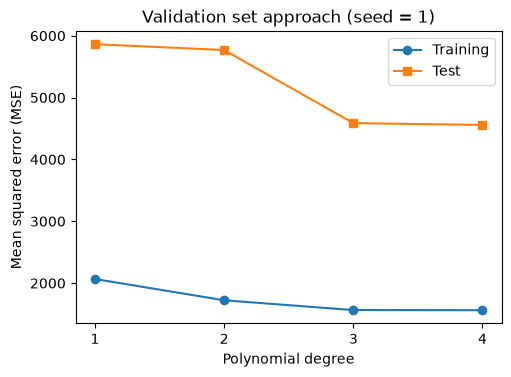

In [19]:
plt.figure(figsize=(5.5, 3.8))
plt.plot(results_val["degree"], results_val["mse_train"], "o-", label="Training")
plt.plot(results_val["degree"], results_val["mse_test"],  "s-", label="Test")
plt.xticks([1, 2, 3, 4])
plt.xlabel("Polynomial degree")
plt.ylabel("Mean squared error (MSE)")
plt.title("Validation set approach (seed = 1)")
plt.legend()
plt.show()

The generated plot shows the training error to fall steadily and very slowly, which is expected since the more flexible the model is (the highest the degree), the better fit is has on the data it was trained on. As for the test error, which estimates the variance of predictions for new observations, we can see that it drops slowly until degree 2 and then it drops abruptly for degrees 3 and 4. 

The goal is to have a small variance of new predictions. Based on the generated plot as we said above, going from degree 2 to 3 lowers the test MSE a lot showing a clear improvement, while in the step from degree 3 to 4, the change in MSE is negligible. Degree 4 has a slightly smaller error but it adds extra flexibility, so it's not worth it. The degree 3 and 4 models predict almost equally well, so we can choose the **degree 3** model that is also simpler. However, this is the case of the specific seed and the results could change by using another seed.

Step 4. Repeat the procedure ten times with different random seeds.

In [ ]:
random.seed(3)
seeds_random = random.sample(range(200), 10)    # 10 different random seeds
print(seeds_random)

[60, 151, 139, 33, 94, 154, 121, 160, 148, 16]


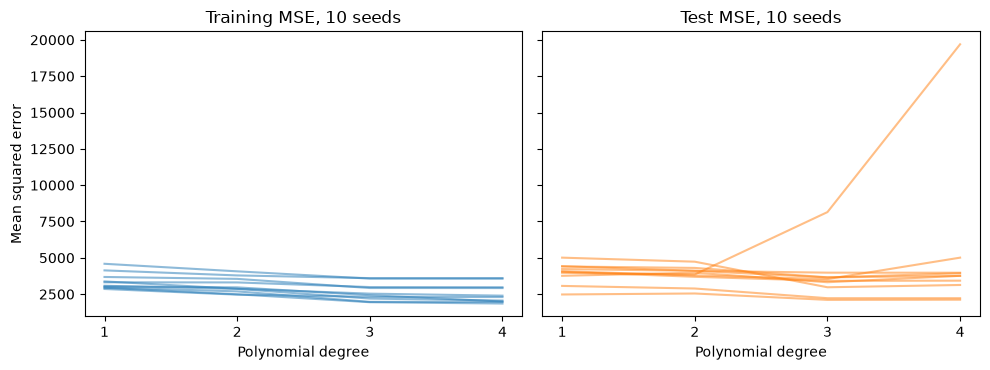

In [32]:
all_results = []
for s in seeds_random:
    train, test = split_in_half(air_pollution, seed=s) # new split for each seed
    r = validation_mse(train=train, test=test) # fit the model using the new split
    r["seed"] = s
    all_results.append(r)
all_results = pd.concat(all_results, ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for s, g in all_results.groupby("seed"):
    axes[0].plot(g["degree"], g["mse_train"], color="tab:blue", alpha=0.5)
    axes[1].plot(g["degree"], g["mse_test"],  color="tab:orange", alpha=0.5)
axes[0].set_title("Training MSE, 10 seeds")
axes[1].set_title("Test MSE, 10 seeds")
for a in axes:
    a.set_xticks([1, 2, 3, 4]); a.set_xlabel("Polynomial degree")
axes[0].set_ylabel("Mean squared error")
plt.tight_layout(); plt.show()

In [31]:
# check how many times each degree wins
best = all_results.loc[all_results.groupby("seed")["mse_test"].idxmin(), ["seed", "degree"]]
print(best["degree"].value_counts().sort_index())

degree
2    1
3    7
4    2
Name: count, dtype: int64


For lower degrees (1–2) the error curves have a relatively similar pattern and are quite stable across seeds, with values in a small range. For higher densities (3-4) the results for different seeds are diverging more. Most of the seeds, continue having the same pattern where the test error drops slightly at degree 3 but there are at least two seeds as we can see from the right plot, for which the error gets higher as the degree increases. This shows that the estimated variance can change considerably for different splits into training and validation sets, so the validation set approach isn't very stable towards its results and for choosing the best polynomial degree for the model.

### 2) K-fold cross-validation

In this method, we split the data into *K* equally sized folds and during the training we hold out one fold, fit the model on the other *K* − 1 folds and compute the MSE on the held-out fold. We repeat these steps so each fold is held out once and then average the *K* MSEs. By averaging the resulting estimates of the error, we get a good estimate of the variance of a new prediction: $$\hat V(\hat f(x_0)) = \frac{1}{K}\sum_{k=1}^K MSE_k$$
Step 1. We are going to use a 2 degree polynomial to estimate the variance of predictions, with the K-fold cross-validation approach holding out K=3 sets.

In [ ]:
def kfold_mse(df, p, K, seed):
    rng = np.random.default_rng(seed) # random number generator, fixed by the seed
    idx = rng.permutation(len(df)) # shuffle the row numbers into a random order
    folds = np.array_split(idx, K) # split the shuffled rows into K=3 groups          
    fold_mse = [] # empty list to collect one MSE per fold

    for fold in folds: # loop over the folds (take each fold as the test fold in turns)                                       
        test = df.iloc[fold] # the rows in the held-out fold                         
        train = df.drop(df.index[fold]) # all the other rows                  
        coefs = fit_poly(train['JULT'], train['MORT'], p)  # fit the polynomial on the training data only   
        fold_mse.append(mse(coefs, test['JULT'], test['MORT'])) # measure the error on the test fold and store it

    return np.mean(fold_mse), fold_mse # average of the K errors as an estimate of the variance of a new prediction and the K-fold errors for all the K-folds

est, per_fold = kfold_mse(air_pollution, p=2, K=3, seed=1)
print("MSE per fold:", np.round(per_fold, 1))
print("K-fold estimate of prediction variance:", round(est, 1))

MSE per fold: [3411.7 4168.5 4217.1]
K-fold estimate of prediction variance: 3932.4


Step 2. Repeat the procedure ten times with different random seeds.

In [56]:
kf_estimates = [] # list to collect one K-fold estimate per seed
kf_per_fold = []         # one list of 3 fold errors per seed

for s in seeds_random: # loop over the 10 random seeds
    est, per_fold = kfold_mse(air_pollution, p=2, K=3, seed=s)
    kf_estimates.append(est)
    kf_per_fold.append(per_fold)

kf = pd.DataFrame({"seed": seeds_random, "kfold_mse": kf_estimates})
kf[["fold_1", "fold_2", "fold_3"]] = pd.DataFrame(kf_per_fold)

print(kf.round(1).to_string(index=False))
print(kf["kfold_mse"].min().round(1))
print(kf["kfold_mse"].max().round(1))

 seed  kfold_mse  fold_1  fold_2  fold_3
   60     3712.8  4074.7  4987.5  2076.0
  151     4925.0  5966.0  3966.4  4842.8
  139     3488.5  3875.2  1752.1  4838.3
   33     4082.1  4581.3  4816.3  2848.8
   94     4273.5  4423.9  3796.9  4599.7
  154     3636.7  4441.5  3774.3  2694.2
  121     4438.4  3398.3  5335.2  4581.9
  160     3613.7  4647.9  3723.4  2469.9
  148     3428.7  2837.4  3167.1  4281.6
   16     3616.6  4437.2  4106.4  2306.1
3428.7
4925.0


Repeating the procedure of K-fold cross-validation approach with ten other random seeds gave estimates between 3428.7 and 4925. The result we got from the first run above is 3932.4 for seed 1, which is inside the range given from the other seeds' runs. This shows that the estimates across different seeds using the k-fold method are relatively close. Although individual folds differ within the seeds, averaging over the K folds and using this kfold estimate, makes the overall estimate much less sensitive to how the data happen to be divided. Every observation is used for testing exactly once, so the estimate is influenced by all observations and the way the data split is not a bias. Also, it's a fact that averages fluctuate less than single numbers.

### 3) Bootstrap

Estimate the standard error of the slope of the line in the Poisson regression of the birds over time. The Poisson model that will be used for fitting is the following: $Y|x_i \sim Po(\lambda(x_i))$ with $\log \lambda(x_i) = \beta_0 + \beta_1 x_i$, where *x* is the year (the predictor).

The steps for bootstraping are:
1. Take a bootstrap sample, meaning the yr-count pairs from the bird_counts.csv dataset with replacement.
2. Refit the Poisson regression model on this bootstrap sample and store the slope.
3. Repeat *B* times.
4. The standard deviation of the *B* slopes is the bootstrap standard error.


Load bird_count.csv data

In [57]:
birds = pd.read_csv('data/bird_count.csv')

- Fit the Poisson GLM model by maximum likelihood (the functions are from the second exercise)

In [66]:
def log_likelihood(beta, year, count):
    beta0, beta1 = beta
    lt = beta0 + beta1 * year
    return np.sum(-np.exp(lt) + count * lt - gammaln(count + 1))

def neg_log_likelihood(beta, year, count):
    return -log_likelihood(beta, year, count)

# maximum likelihood slope 
def fit_slope(year, count):
    x = year - year.mean()                                   # centre the years
    start = np.array([np.log(count.mean()), 0.0])            # starting values for beta0 and beta1
    result = minimize(neg_log_likelihood, start, args=(x, count), method="Nelder-Mead") # optimize the log-likelihood by minimizing the negative log-likelihood
    return result.x[1]                                       # the slope beta1

slope_hat = fit_slope(birds['yr'], birds['count'])
print(round(slope_hat, 5))  

-0.03244


As we can see the estimated parameter of β1 is -0.03244 as reported to the exercise.

- Use the bootstrap approach to approximate the standard error of the estimate of the slope parameter

In [72]:
rng = np.random.default_rng(1)
B = 10000 # number of bootstrap samples
n = len(birds['yr']) # number of observations
slopes = np.empty(B) # empty array for B slopes, filled in the loop

for b in range(B): # repeat the procedure B times
    i = rng.integers(0, n, size=n) # draw n row numbers between 0 and n-1 with replacement to get the bootstrapped sample                        
    slopes[b] = fit_slope(birds['yr'][i], birds['count'][i])                 # refit the Poisson model by maximum likelihood and store the slope β1

slope_mean = np.sum(slopes) / B # average of the B bootstrap slopes
slope_var = np.sum((slopes - slope_mean) ** 2) / (B - 1) # bootstrap sample variance
se_boot = np.sqrt(slope_var) # bootstrap estimated standard error (the square root of the variance)

print(se_boot)

0.034054204171715716
